# Extraction of high PIP variants from CSs and studying their fucntional consequnce

This notebook about ploting the VEP consecunce of variants with high PIP (>=0.95) for difffrent credible sets.

In [1]:
!gcloud auth application-default login

Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Faccounts.reauth&state=20iWvxdxskM0t948vS8fWVpCUR5BJv&access_type=offline&code_challenge=fzOBguR5FSLQFOuRd8P4k56xB6MHGsIFWIWm5DKj9HM&code_challenge_method=S256


Credentials saved to file: [/Users/yt4/.config/gcloud/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).

Quota project "open-targets-genetics-dev" was added to ADC which can be used by Google client libraries for billing and quota. Note that some services may still bill the project owning

In [1]:
import numpy as np
from typing import Any
import os
import hail as hl
import pyspark.sql.functions as f
import pandas as pd

from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.study_locus import StudyLocus
from gentropy.dataset.summary_statistics import SummaryStatistics
from gentropy.dataset.l2g_prediction import L2GPrediction
hail_dir = os.path.dirname(hl.__file__)
session = Session(hail_home=hail_dir, start_hail=True, extended_spark_conf={"spark.driver.memory": "12g","spark.kryoserializer.buffer.max": "500m","spark.driver.maxResultSize":"2g"})
hl.init(sc=session.spark.sparkContext, log="/dev/null")

Loading BokehJS ...

24/04/17 09:56:41 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


24/04/17 09:56:42 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


pip-installed Hail requires additional configuration options in Spark referring
  to the path to the Hail Python module directory HAIL_DIR,
  e.g. /path/to/python/site-packages/hail:
    spark.jars=HAIL_DIR/backend/hail-all-spark.jar
    spark.driver.extraClassPath=HAIL_DIR/backend/hail-all-spark.jar
    spark.executor.extraClassPath=./hail-all-spark.jarRunning on Apache Spark version 3.3.4
SparkUI available at http://mib118093s.internal.sanger.ac.uk:4041
Welcome to
     __  __     <>__
    / /_/ /__  __/ /
   / __  / _ `/ / /
  /_/ /_/\_,_/_/_/   version 0.2.127-bb535cd096c5
LOGGING: writing to /dev/null


In [2]:
path_to_cs=["gs://genetics_etl_python_playground/releases/24.03/credible_set/gwas_catalog_PICSed_curated_associations/",
            "gs://genetics_etl_python_playground/releases/24.03/credible_set/gwas_catalog_PICSed_summary_statistics",
            "gs://genetics_etl_python_playground/releases/24.03/credible_set/finngen_susie"]
cred_sets=StudyLocus.from_parquet(session=session,path=path_to_cs)

genes=session.spark.read.parquet("gs://genetics_etl_python_playground/static_assets/targets")
genes=genes.withColumnRenamed("id","geneId")


vi_path="gs://genetics_etl_python_playground/releases/24.03/variant_index"
vi=session.spark.read.parquet(vi_path)


In [3]:
PIP_thr=0.95

## VEP for variant with max posterior probability in locus

In [45]:
cred_sets_df=cred_sets.df
cred_sets_df=cred_sets_df.filter(f.col("variantId").isNotNull())
#cred_sets_df.count()

In [46]:
#cred_sets_df.show(1)

In [47]:
from pyspark.sql.functions import expr

cred_sets_df = cred_sets_df.withColumn(
    "max_posteriorProbability",
    expr("array_max(transform(locus, x -> x.posteriorProbability))")
)

cred_sets_df = cred_sets_df.withColumn(
    "filtered_locus",
    expr("locus[array_position(transform(locus, x -> x.posteriorProbability), max_posteriorProbability) - 1].variantId")
)

cred_sets_df = cred_sets_df.withColumn(
    "filtered_posteriorProbability",
    expr("locus[array_position(transform(locus, x -> x.posteriorProbability), max_posteriorProbability) - 1].posteriorProbability")
)

In [27]:
#cred_sets_df.show(20)

In [48]:
cred_sets_df=cred_sets_df.filter(f.col("filtered_locus").isNotNull())

In [37]:
#cred_sets_df.count()

In [49]:
category_counts = cred_sets_df.groupBy("finemappingMethod").count().show()
print(category_counts)

+-----------------+------+
|finemappingMethod| count|
+-----------------+------+
|             pics|677325|
|            SuSie| 13966|
+-----------------+------+

None


In [39]:
#vi.show(1)

In [50]:
#cred_sets_df_susie=cred_sets_df.filter(f.col("fineMappingMethod")=="SuSie")
cred_sets_df_susie=cred_sets_df

In [51]:
cred_sets_df_susie=cred_sets_df_susie.join(vi,cred_sets_df_susie.filtered_locus==vi.variantId)
cred_sets_df_susie = cred_sets_df_susie.dropDuplicates(["filtered_locus"])

In [52]:
cred_sets_df_susie.count()

307692

In [53]:
cred_sets_df_susie.show(3)

+--------------------+----------------+----------+---------+------+------------+-----------+--------------+--------------+-------------------------------+-------------+-------------------+--------------------+-----------------+----------------+------------------+----------+--------------------+--------------------+------------------------+----------------+-----------------------------+----------------+---------+---------------+---------------+-------------+-----------+----------+--------------------+------------------+---------------------+--------------+----------+
|        studyLocusId|       variantId|chromosome| position|region|     studyId|       beta|pValueMantissa|pValueExponent|effectAlleleFrequencyFromSource|standardError|subStudyDescription|     qualityControls|finemappingMethod|credibleSetIndex|credibleSetlog10BF|sampleSize|               ldSet|               locus|max_posteriorProbability|  filtered_locus|filtered_posteriorProbability|       variantId| position|referenceAll

In [54]:
category_counts = cred_sets_df_susie.groupBy("mostSevereConsequence").count().show()
print(category_counts)

+---------------------+------+
|mostSevereConsequence| count|
+---------------------+------+
| upstream_gene_var...| 16560|
|       intron_variant|192338|
| mature_miRNA_variant|    11|
| TF_binding_site_v...|   758|
| non_coding_transc...| 10212|
| splice_region_var...|   711|
|           start_lost|    17|
|     inframe_deletion|   104|
|          stop_gained|   176|
| regulatory_region...|  8748|
|   synonymous_variant|  1734|
|   intergenic_variant| 49282|
| downstream_gene_v...| 12272|
| splice_acceptor_v...|    76|
|        TFBS_ablation|     2|
|  3_prime_UTR_variant|  6847|
| splice_donor_variant|   108|
|     missense_variant|  4422|
|   frameshift_variant|   149|
|  5_prime_UTR_variant|  3077|
+---------------------+------+
only showing top 20 rows

None


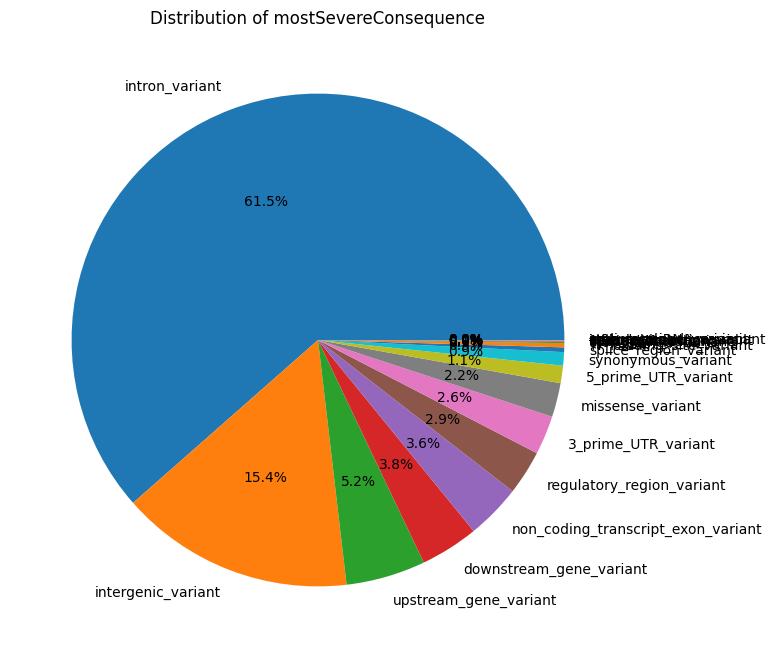

In [55]:
import matplotlib.pyplot as plt

# Convert to Pandas DataFrame
pandas_df = cred_sets_df_susie.toPandas()

# Count the instances of each category
category_counts = pandas_df['mostSevereConsequence'].value_counts()

# Plot pie chart
plt.figure(figsize=(10, 8))
category_counts.plot.pie(autopct='%1.1f%%')
plt.title('Distribution of mostSevereConsequence')
plt.ylabel('')
plt.show()

In [21]:
#!pip install matplotlib

## VEP for all methods for variants for PIP>=PIP_thr

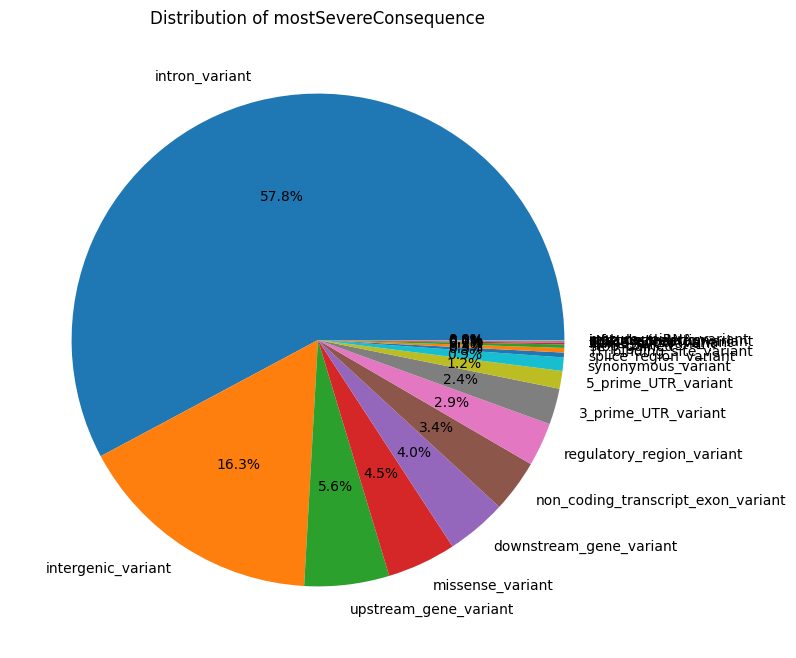

In [58]:
cred_sets_df=cred_sets.df
cred_sets_df=cred_sets_df.filter(f.col("variantId").isNotNull())
#cred_sets_df.count()

from pyspark.sql.functions import expr

cred_sets_df = cred_sets_df.withColumn(
    "filtered_locus",
    expr("filter(locus, x -> x.posteriorProbability >="+str(PIP_thr)+")").getItem(0)["variantId"]
)

cred_sets_df = cred_sets_df.withColumn(
    "filtered_posteriorProbability",
    expr("filter(locus, x -> x.posteriorProbability >="+str(PIP_thr)+")").getItem(0)["posteriorProbability"]
)

cred_sets_df=cred_sets_df.filter(f.col("filtered_locus").isNotNull())

#cred_sets_df_susie=cred_sets_df.filter(f.col("fineMappingMethod")=="SuSie")
cred_sets_df_susie=cred_sets_df

cred_sets_df_susie=cred_sets_df_susie.join(vi,cred_sets_df_susie.filtered_locus==vi.variantId)
cred_sets_df_susie = cred_sets_df_susie.dropDuplicates(["filtered_locus"])

import matplotlib.pyplot as plt

# Convert to Pandas DataFrame
pandas_df = cred_sets_df_susie.toPandas()

# Count the instances of each category
category_counts = pandas_df['mostSevereConsequence'].value_counts()

# Plot pie chart
plt.figure(figsize=(10, 8))
category_counts.plot.pie(autopct='%1.1f%%')
plt.title('Distribution of mostSevereConsequence')
plt.ylabel('')
plt.show()

## VEP for SuSie for variants for PIP>=PIP_thr

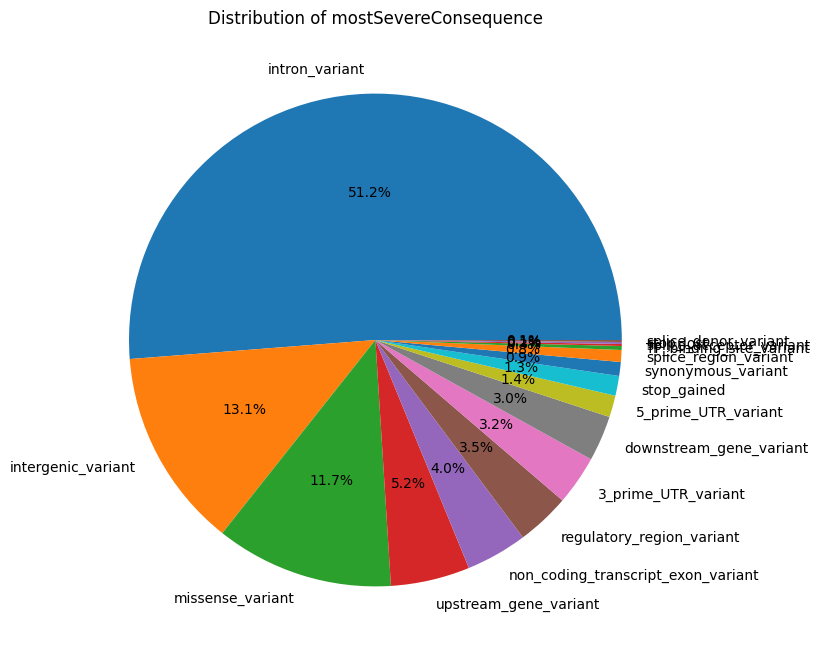

In [59]:
cred_sets_df=cred_sets.df
cred_sets_df=cred_sets_df.filter(f.col("variantId").isNotNull())
#cred_sets_df.count()

from pyspark.sql.functions import expr

cred_sets_df = cred_sets_df.withColumn(
    "filtered_locus",
    expr("filter(locus, x -> x.posteriorProbability >="+str(PIP_thr)+")").getItem(0)["variantId"]
)

cred_sets_df = cred_sets_df.withColumn(
    "filtered_posteriorProbability",
    expr("filter(locus, x -> x.posteriorProbability >="+str(PIP_thr)+")").getItem(0)["posteriorProbability"]
)

cred_sets_df=cred_sets_df.filter(f.col("filtered_locus").isNotNull())

cred_sets_df_susie=cred_sets_df.filter(f.col("fineMappingMethod")=="SuSie")
#cred_sets_df_susie=cred_sets_df

cred_sets_df_susie=cred_sets_df_susie.join(vi,cred_sets_df_susie.filtered_locus==vi.variantId)
cred_sets_df_susie = cred_sets_df_susie.dropDuplicates(["filtered_locus"])

import matplotlib.pyplot as plt

# Convert to Pandas DataFrame
pandas_df = cred_sets_df_susie.toPandas()

# Count the instances of each category
category_counts = pandas_df['mostSevereConsequence'].value_counts()

# Plot pie chart
plt.figure(figsize=(10, 8))
category_counts.plot.pie(autopct='%1.1f%%')
plt.title('Distribution of mostSevereConsequence')
plt.ylabel('')
plt.show()

## VEP for pics for variants for PIP>=PIP_thr

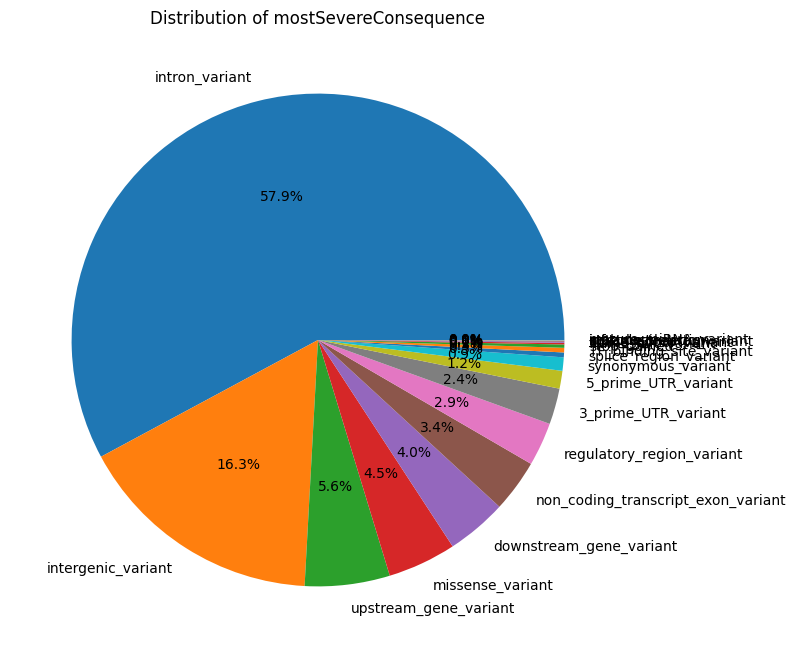

In [61]:
cred_sets_df=cred_sets.df
cred_sets_df=cred_sets_df.filter(f.col("variantId").isNotNull())
#cred_sets_df.count()

from pyspark.sql.functions import expr

cred_sets_df = cred_sets_df.withColumn(
    "filtered_locus",
    expr("filter(locus, x -> x.posteriorProbability >="+str(PIP_thr)+")").getItem(0)["variantId"]
)

cred_sets_df = cred_sets_df.withColumn(
    "filtered_posteriorProbability",
    expr("filter(locus, x -> x.posteriorProbability >="+str(PIP_thr)+")").getItem(0)["posteriorProbability"]
)

cred_sets_df=cred_sets_df.filter(f.col("filtered_locus").isNotNull())

cred_sets_df_susie=cred_sets_df.filter(f.col("fineMappingMethod")=="pics")
#cred_sets_df_susie=cred_sets_df

cred_sets_df_susie=cred_sets_df_susie.join(vi,cred_sets_df_susie.filtered_locus==vi.variantId)
cred_sets_df_susie = cred_sets_df_susie.dropDuplicates(["filtered_locus"])

import matplotlib.pyplot as plt

# Convert to Pandas DataFrame
pandas_df = cred_sets_df_susie.toPandas()

# Count the instances of each category
category_counts = pandas_df['mostSevereConsequence'].value_counts()

# Plot pie chart
plt.figure(figsize=(10, 8))
category_counts.plot.pie(autopct='%1.1f%%')
plt.title('Distribution of mostSevereConsequence')
plt.ylabel('')
plt.show()

## Old gold standard list

In [4]:
gs=session.spark.read.csv("gs://genetics-portal-dev-analysis/yt4/GS_positives.txt",sep="\t",header=True)

In [5]:
gs.show()

+--------------+-----+---------+---+---+---------------+------------------+-------------+------+-----------------+--------------------+--------------------+------+------------+-----------------+
|      study_id|chrom|      pos|ref|alt|        gene_id|proteinAttenuation|gs_confidence|gs_set|gs_confidence_num|gold_standard_status|      trait_reported|source|has_sumstats|chrom_pos_ref_alt|
+--------------+-----+---------+---+---+---------------+------------------+-------------+------+-----------------+--------------------+--------------------+------+------------+-----------------+
| GCST002442_19|    5|177415473|  T|  C|ENSG00000131187|       0.260109636|         High|ProGeM|                1|                   1|Blood metabolite ...|  GCST|       FALSE|  5_177415473_T_C|
|GCST002443_128|   19| 12899706|  A|  G|ENSG00000105607|       0.116959018|         High|ProGeM|                1|                   1|Blood metabolite ...|  GCST|       FALSE|  19_12899706_A_G|
|  GCST002364_9|   19| 32

In [6]:
gs=gs.join(vi,gs.chrom_pos_ref_alt==vi.variantId)
cred_sets_df_susie = gs.dropDuplicates(["chrom_pos_ref_alt"])
cred_sets_df_susie.count()

427

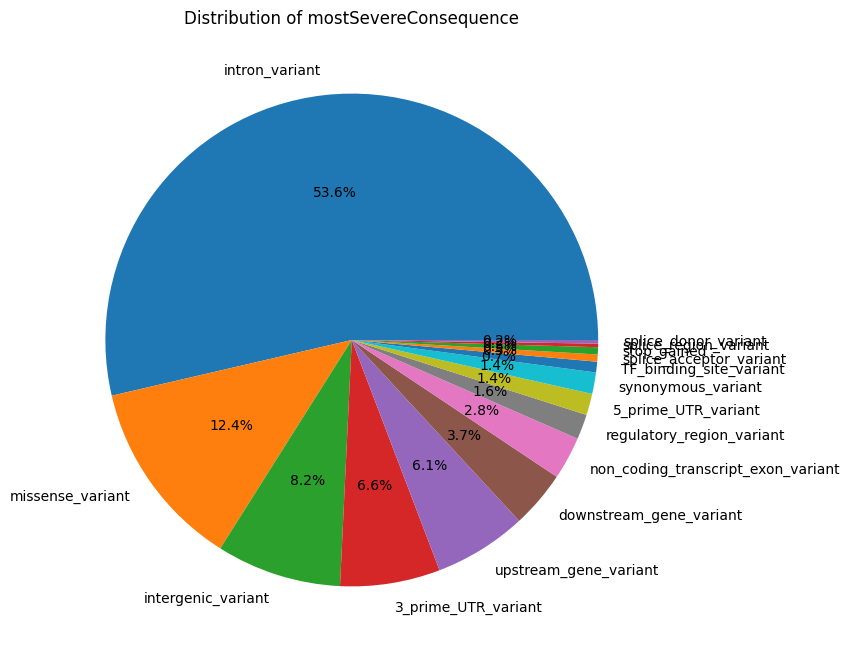

In [7]:


import matplotlib.pyplot as plt

# Convert to Pandas DataFrame
pandas_df = cred_sets_df_susie.toPandas()

# Count the instances of each category
category_counts = pandas_df['mostSevereConsequence'].value_counts()

# Plot pie chart
plt.figure(figsize=(10, 8))
category_counts.plot.pie(autopct='%1.1f%%')
plt.title('Distribution of mostSevereConsequence')
plt.ylabel('')
plt.show()

In [8]:
gs_json=session.spark.read.json("gs://genetics_etl_python_playground/releases/24.03/locus_to_gene_gold_standard.json")

In [10]:
gs_json.printSchema()

root
 |-- association_info: struct (nullable = true)
 |    |-- ancestry: array (nullable = true)
 |    |    |-- element: string (containsNull = true)
 |    |-- doi: string (nullable = true)
 |    |-- gwas_catalog_id: string (nullable = true)
 |    |-- neg_log_pval: double (nullable = true)
 |    |-- otg_id: string (nullable = true)
 |    |-- pubmed_id: string (nullable = true)
 |    |-- url: string (nullable = true)
 |-- gold_standard_info: struct (nullable = true)
 |    |-- evidence: array (nullable = true)
 |    |    |-- element: struct (containsNull = true)
 |    |    |    |-- class: string (nullable = true)
 |    |    |    |-- confidence: string (nullable = true)
 |    |    |    |-- curated_by: string (nullable = true)
 |    |    |    |-- description: string (nullable = true)
 |    |    |    |-- pubmed_id: string (nullable = true)
 |    |    |    |-- source: string (nullable = true)
 |    |-- gene_id: string (nullable = true)
 |    |-- highest_confidence: string (nullable = true)
 

In [16]:
from gentropy.datasource.open_targets.l2g_gold_standard import OpenTargetsL2GGoldStandard
from gentropy.dataset.v2g import V2G

In [31]:
gs_json=session.spark.read.json("gs://genetics-portal-dev-analysis/yt4/otg_gs_230511.json")
#gs_curated=OpenTargetsL2GGoldStandard.parse_positive_curation(gs_json)
#gs_curated.count()

In [36]:
v2g = V2G.from_parquet(session, "gs://genetics_etl_python_playground/releases/24.03/variant_to_gene")
#v2g.df.count()
gs_curated=OpenTargetsL2GGoldStandard.as_l2g_gold_standard(gold_standard_curation=gs_json,v2g=v2g)


In [37]:
df=gs_curated.df
df.show(1)

+----------------+--------------------+------------+-------------+---------------+---------------+
|       variantId|        studyLocusId|     studyId|      sources|goldStandardSet|         geneId|
+----------------+--------------------+------------+-------------+---------------+---------------+
|10_112613140_G_C|-5386572034008893618|GCST90061435|[ot_platform]|       negative|ENSG00000119913|
+----------------+--------------------+------------+-------------+---------------+---------------+
only showing top 1 row



In [43]:
df=df.filter(f.col("goldStandardSet")=="positive")
df=df.select("studyLocusId")
df.count()

1149

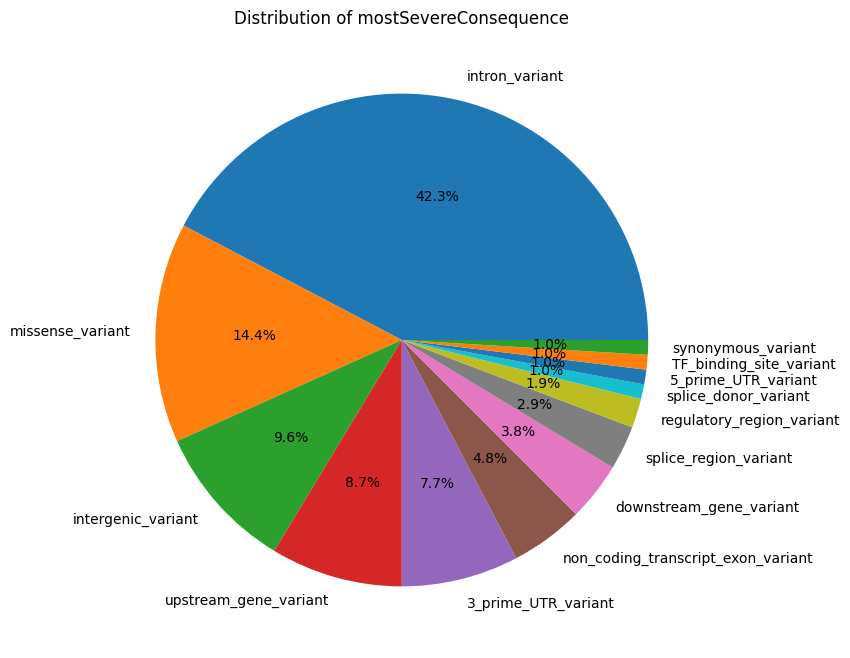

In [62]:
cred_sets_df=cred_sets.df
cred_sets_df=cred_sets_df.filter(f.col("variantId").isNotNull())
cred_sets_df=cred_sets_df.join(df,"studyLocusId","inner")
#cred_sets_df.count()

from pyspark.sql.functions import expr

cred_sets_df = cred_sets_df.withColumn(
    "filtered_locus",
    expr("filter(locus, x -> x.posteriorProbability >="+str(PIP_thr)+")").getItem(0)["variantId"]
)

cred_sets_df = cred_sets_df.withColumn(
    "filtered_posteriorProbability",
    expr("filter(locus, x -> x.posteriorProbability >="+str(PIP_thr)+")").getItem(0)["posteriorProbability"]
)

cred_sets_df=cred_sets_df.filter(f.col("filtered_locus").isNotNull())

#cred_sets_df_susie=cred_sets_df.filter(f.col("fineMappingMethod")=="SuSie")
cred_sets_df_susie=cred_sets_df

cred_sets_df_susie=cred_sets_df_susie.join(vi,cred_sets_df_susie.filtered_locus==vi.variantId)
cred_sets_df_susie = cred_sets_df_susie.dropDuplicates(["filtered_locus"])

import matplotlib.pyplot as plt

# Convert to Pandas DataFrame
pandas_df = cred_sets_df_susie.toPandas()

# Count the instances of each category
category_counts = pandas_df['mostSevereConsequence'].value_counts()

# Plot pie chart
plt.figure(figsize=(10, 8))
category_counts.plot.pie(autopct='%1.1f%%')
plt.title('Distribution of mostSevereConsequence')
plt.ylabel('')
plt.show()

# eQTLs

In [4]:
path_to_cs=["gs://genetics_etl_python_playground/releases/24.03/credible_set/eqtl_catalogue_susie/"]
cred_sets=StudyLocus.from_parquet(session=session,path=path_to_cs)

si_eqtl=StudyIndex.from_parquet(session=session,path="gs://genetics_etl_python_playground/releases/24.03/study_index/eqtl_catalogue/study_index/")

In [5]:
category_counts=si_eqtl.df.groupBy("studyType").count().show()
print(category_counts)

+---------+-------+
|studyType|  count|
+---------+-------+
|     sqtl| 212830|
|     pqtl|    802|
|    tuqtl| 360639|
|     eqtl|1227044|
+---------+-------+

None


In [6]:
si_tmp=si_eqtl.df.filter(f.col("studyType")=="tuqtl").select("studyId")
cred_sets_df=cred_sets.df
cred_sets_df=cred_sets_df.filter(f.col("variantId").isNotNull())
cred_sets_df = cred_sets_df.join(si_tmp, on="studyId", how="inner")
cred_sets_df.count()

406948

In [7]:
si_tmp=si_eqtl.df.filter(f.col("studyType")=="sqtl").select("studyId")
cred_sets_df=cred_sets.df
cred_sets_df=cred_sets_df.filter(f.col("variantId").isNotNull())
cred_sets_df = cred_sets_df.join(si_tmp, on="studyId", how="inner")
cred_sets_df.count()

231752

## eQTLs

In [34]:
si_tmp=si_eqtl.df.filter(f.col("studyType")=="eqtl").select("studyId")
cred_sets_df=cred_sets.df
cred_sets_df=cred_sets_df.filter(f.col("variantId").isNotNull())
cred_sets_df = cred_sets_df.join(si_tmp, on="studyId", how="inner")
cred_sets_df.count()

1414878

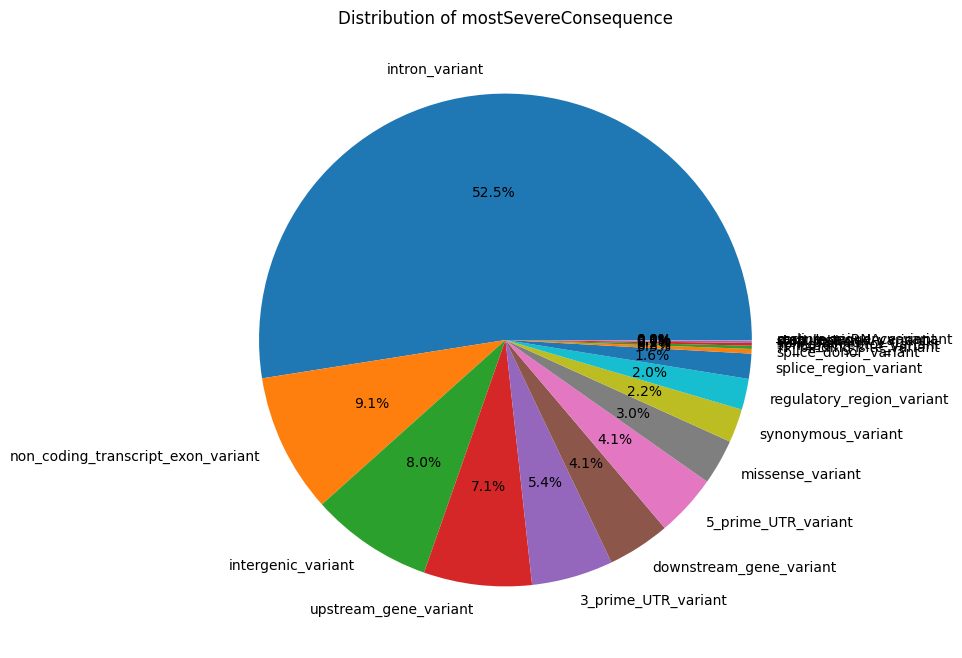

In [35]:
from pyspark.sql.functions import expr

cred_sets_df = cred_sets_df.withColumn(
    "filtered_locus",
    expr("filter(locus, x -> x.posteriorProbability >="+str(PIP_thr)+")").getItem(0)["variantId"]
)

cred_sets_df = cred_sets_df.withColumn(
    "filtered_posteriorProbability",
    expr("filter(locus, x -> x.posteriorProbability >="+str(PIP_thr)+")").getItem(0)["posteriorProbability"]
)

cred_sets_df=cred_sets_df.filter(f.col("filtered_locus").isNotNull())

#cred_sets_df_susie=cred_sets_df.filter(f.col("fineMappingMethod")=="SuSie")
cred_sets_df_susie=cred_sets_df

cred_sets_df_susie=cred_sets_df_susie.join(vi,cred_sets_df_susie.filtered_locus==vi.variantId)
cred_sets_df_susie = cred_sets_df_susie.dropDuplicates(["filtered_locus"])

import matplotlib.pyplot as plt

# Convert to Pandas DataFrame
pandas_df = cred_sets_df_susie.toPandas()

# Count the instances of each category
category_counts = pandas_df['mostSevereConsequence'].value_counts()

# Plot pie chart
plt.figure(figsize=(10, 8))
category_counts.plot.pie(autopct='%1.1f%%')
plt.title('Distribution of mostSevereConsequence')
plt.ylabel('')
plt.show()

## pQTLs

In [36]:
si_tmp=si_eqtl.df.filter(f.col("studyType")=="pqtl").select("studyId")
cred_sets_df=cred_sets.df
cred_sets_df=cred_sets_df.filter(f.col("variantId").isNotNull())
cred_sets_df = cred_sets_df.join(si_tmp, on="studyId", how="inner")
cred_sets_df.count()

1772

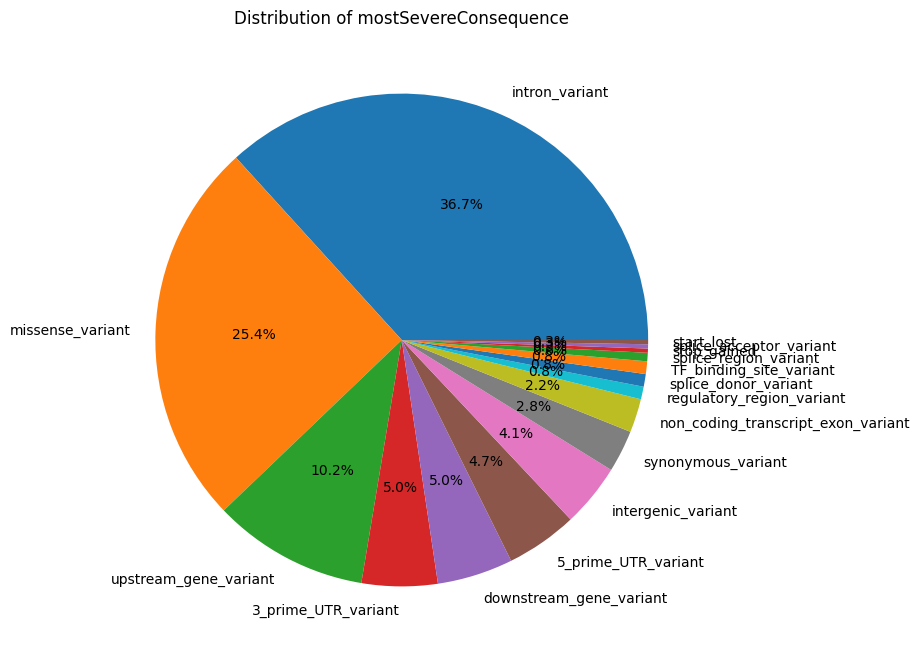

In [37]:
from pyspark.sql.functions import expr

cred_sets_df = cred_sets_df.withColumn(
    "filtered_locus",
    expr("filter(locus, x -> x.posteriorProbability >="+str(PIP_thr)+")").getItem(0)["variantId"]
)

cred_sets_df = cred_sets_df.withColumn(
    "filtered_posteriorProbability",
    expr("filter(locus, x -> x.posteriorProbability >="+str(PIP_thr)+")").getItem(0)["posteriorProbability"]
)

cred_sets_df=cred_sets_df.filter(f.col("filtered_locus").isNotNull())

#cred_sets_df_susie=cred_sets_df.filter(f.col("fineMappingMethod")=="SuSie")
cred_sets_df_susie=cred_sets_df

cred_sets_df_susie=cred_sets_df_susie.join(vi,cred_sets_df_susie.filtered_locus==vi.variantId)
cred_sets_df_susie = cred_sets_df_susie.dropDuplicates(["filtered_locus"])

import matplotlib.pyplot as plt

# Convert to Pandas DataFrame
pandas_df = cred_sets_df_susie.toPandas()

# Count the instances of each category
category_counts = pandas_df['mostSevereConsequence'].value_counts()

# Plot pie chart
plt.figure(figsize=(10, 8))
category_counts.plot.pie(autopct='%1.1f%%')
plt.title('Distribution of mostSevereConsequence')
plt.ylabel('')
plt.show()

In [7]:
cred_sets_df_susie.count()

66994

In [8]:
cred_sets_df_susie.show(3)

+--------------------+----------------+----------+---------+--------------------+--------------------+---------+--------------+--------------+-------------------------------+-------------+-------------------+---------------+-----------------+----------------+------------------+----------+-----+--------------------+----------------+-----------------------------+----------------+---------+---------------+---------------+-------------+-----------+----------+--------------------+------------------+---------------------+------------+----------+
|        studyLocusId|       variantId|chromosome| position|              region|             studyId|     beta|pValueMantissa|pValueExponent|effectAlleleFrequencyFromSource|standardError|subStudyDescription|qualityControls|finemappingMethod|credibleSetIndex|credibleSetlog10BF|sampleSize|ldSet|               locus|  filtered_locus|filtered_posteriorProbability|       variantId| position|referenceAllele|alternateAllele|chromosomeB37|positionB37|allele

In [9]:
genes.show(2)

+---------------+--------------+--------------+--------------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------------+---------+--------------------+--------------------+--------------------+--------------------+--------------------+-----------+--------------------+--------------------+--------------------+----+--------------------+--------------------+--------------+--------------------+--------------------+-----------------+--------------------+
|         geneId|approvedSymbol|       biotype|       transcriptIds| canonicalTranscript|      canonicalExons|     genomicLocation|alternativeGenes|        approvedName|                  go|hallmarks|            synonyms|      symbolSynonyms|        nameSynonyms|functionDescriptions|subcellularLocations|targetClass|     obsoleteSymbols|       obsoleteNames|          constraint| tep|          proteinIds|             dbXrefs|chemicalProbes|          homologues|        tract

In [24]:
cred_sets_df=cred_sets.df
cred_sets_df=cred_sets_df.filter(f.col("variantId").isNotNull())


from pyspark.sql.functions import expr

cred_sets_df = cred_sets_df.withColumn(
    "filtered_locus",
    expr("filter(locus, x -> x.posteriorProbability >="+str(PIP_thr)+")").getItem(0)["variantId"]
)

cred_sets_df = cred_sets_df.withColumn(
    "filtered_posteriorProbability",
    expr("filter(locus, x -> x.posteriorProbability >="+str(PIP_thr)+")").getItem(0)["posteriorProbability"]
)

cred_sets_df=cred_sets_df.filter(f.col("filtered_locus").isNotNull())

from pyspark.sql.functions import col, abs, min

df1=cred_sets_df.select("filtered_locus","chromosome","position")

df2=genes.select("geneId","genomicLocation")

# Perform a cross join
df_cross = df1.crossJoin(df2)
df_cross=df_cross.filter(f.col("chromosome")==f.col("genomicLocation.chromosome"))
# Calculate the distance between positions
df_cross = df_cross.withColumn(
    "distance",
    abs(df_cross["position"] - df_cross["genomicLocation.start"])
)


from pyspark.sql import Window
from pyspark.sql.functions import row_number
# Keep only the rows where the distance is minimal for each variant
window = Window.partitionBy("filtered_locus").orderBy("distance")
df_cross = df_cross.withColumn("rn", row_number().over(window)).filter(f.col("rn") == 1)

df_cross.count()



83742

In [22]:
from pyspark.sql import Window
from pyspark.sql.functions import row_number
# Keep only the rows where the distance is minimal for each variant
window = Window.partitionBy("filtered_locus").orderBy("distance")
df_cross = df_cross.withColumn("rn", row_number().over(window)).where(col("rn") == 1)

# Add the name of the gene and the distance to the closest position as new columns
df1 = df1.withColumn(
    "closest_gene",
    df_cross["geneId"]
)
df1 = df1.withColumn(
    "distance_to_closest_position",
    df_cross["distance"]
)

AnalysisException: Resolved attribute(s) geneId#94 missing from filtered_locus#45446,chromosome#150,position#151 in operator !Project [filtered_locus#45446, chromosome#150, position#151, geneId#94 AS closest_gene#45957].;
!Project [filtered_locus#45446, chromosome#150, position#151, geneId#94 AS closest_gene#45957]
+- Project [filtered_locus#45446, chromosome#150, position#151]
   +- Filter isnotnull(filtered_locus#45446)
      +- Project [studyLocusId#148L, variantId#149, chromosome#150, position#151, region#152, studyId#153, beta#154, pValueMantissa#155, pValueExponent#156, effectAlleleFrequencyFromSource#157, standardError#158, subStudyDescription#159, qualityControls#160, finemappingMethod#161, credibleSetIndex#162, credibleSetlog10BF#163, sampleSize#164, ldSet#165, locus#166, filtered_locus#45446, filter(locus#166, lambdafunction((lambda x#45469.posteriorProbability >= cast(0.95 as double)), lambda x#45469, false))[0].posteriorProbability AS filtered_posteriorProbability#45468]
         +- Project [studyLocusId#148L, variantId#149, chromosome#150, position#151, region#152, studyId#153, beta#154, pValueMantissa#155, pValueExponent#156, effectAlleleFrequencyFromSource#157, standardError#158, subStudyDescription#159, qualityControls#160, finemappingMethod#161, credibleSetIndex#162, credibleSetlog10BF#163, sampleSize#164, ldSet#165, locus#166, filter(locus#166, lambdafunction((lambda x#45447.posteriorProbability >= cast(0.95 as double)), lambda x#45447, false))[0].variantId AS filtered_locus#45446]
            +- Filter isnotnull(variantId#149)
               +- Relation [studyLocusId#148L,variantId#149,chromosome#150,position#151,region#152,studyId#153,beta#154,pValueMantissa#155,pValueExponent#156,effectAlleleFrequencyFromSource#157,standardError#158,subStudyDescription#159,qualityControls#160,finemappingMethod#161,credibleSetIndex#162,credibleSetlog10BF#163,sampleSize#164,ldSet#165,locus#166] parquet
